# Aqueous direct NRR ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for Aqueous direct NRR at 1,000,000 tNH3/year. The notebook shows NPV, LNM, and LCOA distributions, NPV sign counts, and mean annual cost components.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "aqueous_direct_nrr"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tnh3,present_value_total_cost_eur,lcoa_eur_per_tnh3,levelized_net_margin_eur_per_tnh3
0,0,aqueous_direct_nrr,absolute,not_applicable,"1,000,000.000",25,"5,336.764",237.590,24.639,none,...,"2,072,150,332.343",0.000,0.000,"2,334,379,077.693","-1,444,379,077.693","-20,755,187,490.556","10,674,776.189","30,255,738,298.400","2,834.321","-1,944.321"
1,1,aqueous_direct_nrr,absolute,not_applicable,"1,000,000.000",25,"4,937.649",233.812,17.027,none,...,"2,292,101,666.910",0.000,0.000,"2,542,939,967.958","-1,652,939,967.958","-22,582,413,632.645","10,674,776.189","32,082,964,440.489","3,005.493","-2,115.493"
2,2,aqueous_direct_nrr,absolute,not_applicable,"1,000,000.000",25,"4,892.161",228.873,18.198,none,...,"1,664,705,007.280",0.000,0.000,"1,911,776,082.177","-1,021,776,082.177","-15,799,392,440.554","10,674,776.189","25,299,943,248.398","2,370.068","-1,480.068"
3,3,aqueous_direct_nrr,absolute,not_applicable,"1,000,000.000",25,"5,237.739",228.623,20.711,none,...,"2,278,397,844.880",0.000,0.000,"2,527,732,809.223","-1,637,732,809.223","-22,720,170,219.025","10,674,776.189","32,220,721,026.869","3,018.398","-2,128.398"
4,4,aqueous_direct_nrr,absolute,not_applicable,"1,000,000.000",25,"5,154.103",234.159,18.869,none,...,"2,431,084,774.116",0.000,0.000,"2,684,112,829.724","-1,794,112,829.724","-24,305,855,591.946","10,674,776.189","33,806,406,399.790","3,166.943","-2,276.943"


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_net_margin_eur_per_tnh3 = results["levelized_net_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_net_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LNM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LNM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,"-20,635.991","-1,933.154","2,823.154"
std,"4,805.885",450.209,450.209
min,"-32,847.389","-3,077.103","1,723.093"
5%,"-28,511.076","-2,670.883","2,094.293"
50%,"-20,609.349","-1,930.659","2,820.659"
95%,"-12,855.562","-1,204.293","3,560.883"
max,"-8,893.084",-833.093,"3,967.103"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),0,0.000
1,Negative (NPV < 0),100000,1.000


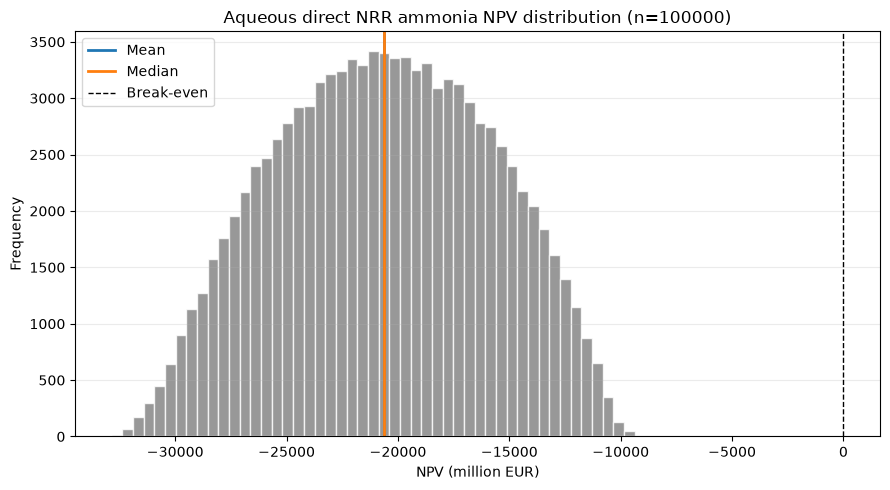

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Aqueous direct NRR ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

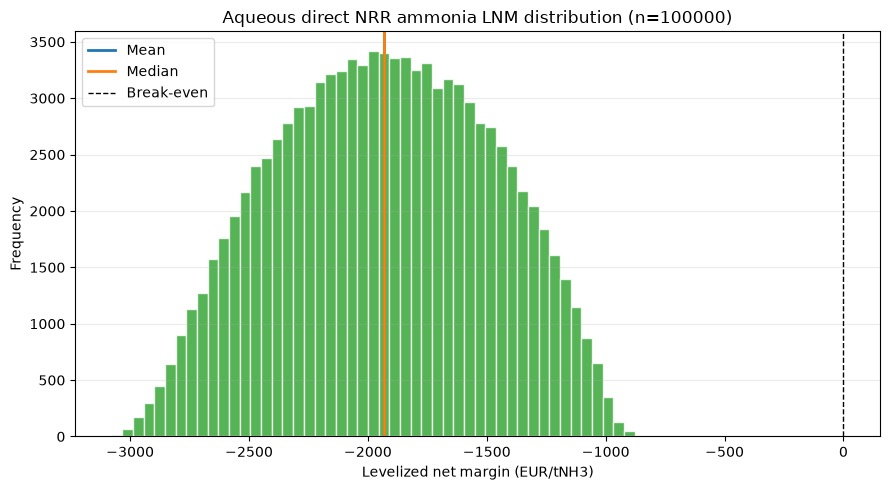

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tnh3,
    title=f"Aqueous direct NRR ammonia LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

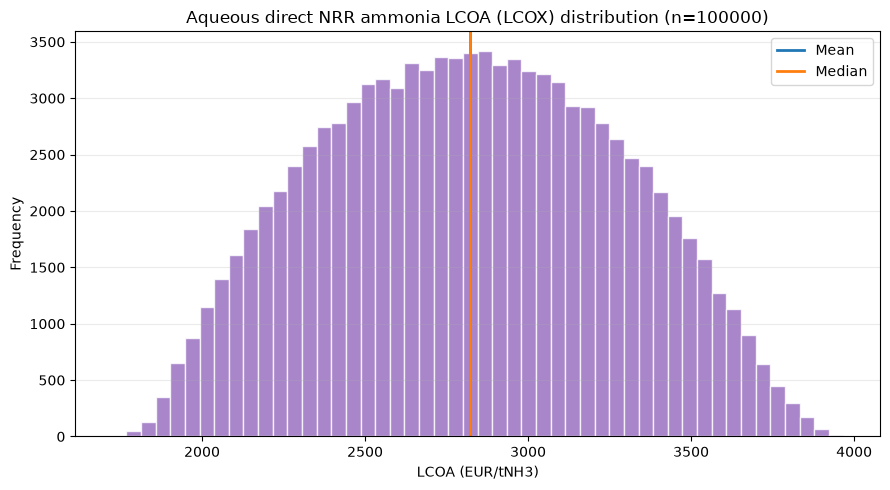

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"Aqueous direct NRR ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                         890.000
annual_fixed_opex_eur                      233.643
annual_variable_opex_eur                    20.197
annual_natural_gas_cost_eur                  0.000
annual_coal_cost_eur                         0.000
annual_biomass_cost_eur                      0.000
annual_fuel_cost_eur                         0.000
annual_electricity_cost_eur              2,094.913
annual_transport_and_storage_cost_eur        0.000
annual_emissions_cost_eur                    0.000
annual_net_cash_flow_eur                -1,458.753
Name: Mean annual value, million EUR, dtype: float64